In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:

transform = transforms.ToTensor()

train_dataset = CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = CIFAR10(
    root='./data',
    train=False,
    transform=transform,
    download=True
)



100%|██████████| 170M/170M [00:05<00:00, 28.4MB/s]


In [4]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [5]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [6]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc':  [],
        'val_loss':   [],
        'val_acc':    [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc  = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc  += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc  = 0.0
        with torch.no_grad():
            for X_val, y_val in _test_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc  += get_batch_accuracy(val_outputs, y_val, len(_test_loader.dataset))

        epoch_val_loss = val_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc =f"{train_acc:.4f}",
            val_loss  =f"{epoch_val_loss:.4f}",
            val_acc   =f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [13]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc  = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device)
            y = y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc  += get_batch_accuracy(output, y, len(_test_loader.dataset))
    return (test_loss / len(_test_loader.dataset)), test_acc

In [10]:

model_cnn = nn.Sequential(
    nn.Conv2d(3, 25, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(25, 50, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(50, 75, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn = model_cnn.to(device)

In [11]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [04:42<00:00, 14.11s/epoch, train_acc=0.8870, train_loss=0.3221, val_acc=0.7519, val_loss=0.8789]


In [14]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

In [18]:
model2 = nn.Sequential(
    nn.Conv2d(3, 8, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(8 * 16 * 16, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

model2 = model2.to(device)

epochs = 20
loss_function2 = nn.CrossEntropyLoss()
optimizer2 = Adam(model2.parameters())

cnn2_res = train(model2, train_loader, test_loader, loss_function2, optimizer2, epochs)

Training: 100%|██████████| 20/20 [03:59<00:00, 11.99s/epoch, train_acc=0.6280, train_loss=1.0575, val_acc=0.5911, val_loss=1.1735]


In [19]:
model3 = nn.Sequential(
    nn.Conv2d(3, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Dropout(.2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Dropout(.3),

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.Dropout(.4),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model3 = model3.to(device)

epochs = 20
loss_function3 = nn.CrossEntropyLoss()
optimizer3 = Adam(model3.parameters())

res3 = train(model3, train_loader, test_loader, loss_function3, optimizer3, epochs)

Training: 100%|██████████| 20/20 [05:31<00:00, 16.55s/epoch, train_acc=0.8086, train_loss=0.5446, val_acc=0.7871, val_loss=0.6492]


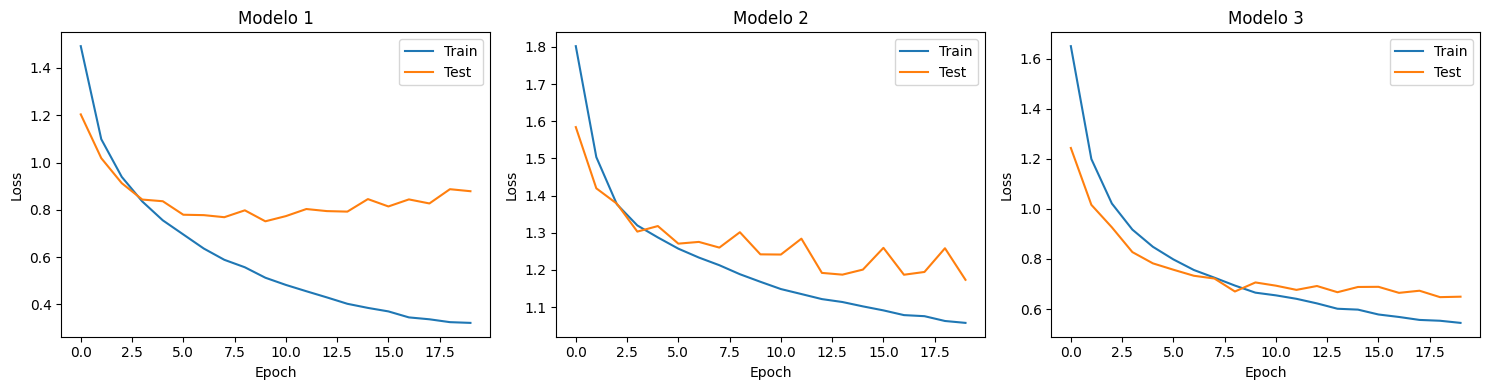

Test Accuracy Modelo 1: 0.7519
Test Accuracy Modelo 2: 0.5911
Test Accuracy Modelo 3: 0.7871
Modelo 1: 0.7519
Modelo 2: 0.5911
Modelo 3: 0.7871

Mejor modelo: Modelo 3 con accuracy de 0.7871


In [25]:

train_losses  = cnn_res['train_loss']
val_losses    = cnn_res['val_loss']
train_losses2 = cnn2_res['train_loss']
val_losses2   = cnn2_res['val_loss']
train_losses3 = res3['train_loss']
val_losses3   = res3['val_loss']


cnn_test_loss,  cnn_test_acc  = test(model_cnn,  test_loader, loss_function)
cnn_test_loss2, cnn_test_acc2 = test(model2, test_loader, loss_function2)
cnn_test_loss3, cnn_test_acc3 = test(model3,     test_loader, loss_function3)

# Curvas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (t_losses, v_losses, title) in enumerate([
    (train_losses,  val_losses,  "Modelo 1"),
    (train_losses2, val_losses2, "Modelo 2"),
    (train_losses3, val_losses3, "Modelo 3"),
]):
    axes[i].plot(t_losses, label='Train')
    axes[i].plot(v_losses, label='Test')
    axes[i].set_title(title)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()

print(f"Test Accuracy Modelo 1: {cnn_test_acc:.4f}")
print(f"Test Accuracy Modelo 2: {cnn_test_acc2:.4f}")
print(f"Test Accuracy Modelo 3: {cnn_test_acc3:.4f}")

resultados = {
    'Modelo 1': cnn_test_acc,
    'Modelo 2': cnn_test_acc2,
    'Modelo 3': cnn_test_acc3,
}

for nombre, acc in resultados.items():
    print(f"{nombre}: {acc:.4f}")

mejor_modelo = max(resultados, key=resultados.get)
print(f"\nMejor modelo: {mejor_modelo} con accuracy de {resultados[mejor_modelo]:.4f}")

## Reflection section

El modelo que tuvo mejores resultados fue el tercero, posiblemente al tener una arquitectura más profunda el modelo tuvo más capacidad para encontrar patrones o detalles, sobre todo si comparamos los resultados con el modelo 2 se pueden ver grandes cambios. También otra ventaja es que este modelo si bien presenta overfitting, no es tan notorio sobre todo si lo comparamos con el modelo 1, donde este modelo llega un punto en el cual su error sube y el train baja generando una brecha muy grande. Por lo cual, finalmente en esta actividad se pudo observar como en este conjunto de datos en específico funcionaron modelos de mayor profundidad permitiendo captar más los patrones de las imagenes.